# 01. Descrição da rede

Este notebook descreve a malha aérea doméstica regular antes de qualquer simulação de fechamento. São duas redes, construídas por `scripts/construir_rede.py` com as escolhas de `docs/modelagem.md`:

- **referência:** 01/04/2024 a 30/04/2024, antes do fechamento do Salgado Filho (SBPA);
- **pós-fechamento:** 04/05/2024 a 30/06/2024, com SBPA fechado.

Nós são aeroportos (código ICAO), arestas são rotas com pelo menos 1 voo por semana, e o peso é a frequência semanal.

**Conteúdo do curso usado neste notebook**

| Conceito | Semana | Seção |
|---|---|---|
| Grafo dirigido, densidade | 2 | 1 |
| Grau de entrada e de saída | 3 | 2 |
| Grau e distribuição de grau | 2 | 3 e 4 |
| Componentes (WCC, SCC), caminhos, distâncias e diâmetro | 4 | 5 |
| Matriz de adjacência | 2 | 6 |
| Triângulos e clustering | 4 | 7 |

In [1]:
import sys
from pathlib import Path
raiz = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(raiz / "src"))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from metricas import resumo_rede, tabela_graus
from rede import carregar_grafo, nome_curto

PASTA_FIG = raiz / "figures"
PASTA_FIG.mkdir(exist_ok=True)

# paleta: azul = referência (abril), laranja = pós-fechamento
COR_REF, COR_POS = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b", "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
pd.set_option("display.precision", 3)

In [2]:
G_ref = carregar_grafo(raiz / "data" / "processed" / "rede_referencia.graphml")
G_pos = carregar_grafo(raiz / "data" / "processed" / "rede_pos_fechamento.graphml")
print("referência:", G_ref.graph["inicio"], "a", G_ref.graph["fim"], "|", G_ref)
print("pós-fechamento:", G_pos.graph["inicio"], "a", G_pos.graph["fim"], "|", G_pos)

referência: 2024-04-01 a 2024-04-30 | DiGraph with 154 nodes and 816 edges
pós-fechamento: 2024-05-04 a 2024-06-30 | DiGraph with 153 nodes and 806 edges


## 1. Tamanho, densidade e direção (Sem. 2)

In [3]:
resumo = pd.DataFrame({"referência": resumo_rede(G_ref), "pós-fechamento": resumo_rede(G_pos)})
resumo.map(lambda x: f"{x:.3f}".rstrip("0").rstrip("."))

,referência,pós-fechamento
nós,154,153
arestas,816,806
densidade,0.035,0.035
grau médio,10.597,10.536
grau mediano,3,4
grau máximo,112,120
rotas com volta (%),95.098,95.285
WCC,1,1
SCC,2,1
maior SCC,153,153


- Em abril, a malha tem **154 aeroportos e 816 rotas**. A densidade é 0,035: só **3,5% dos pares possíveis têm voo direto**. A rede é esparsa, e a maior parte das viagens depende de escalas.
- O grau médio é 10,6, mas a **mediana é 3**. Poucos aeroportos com muitas rotas puxam a média para cima (seção 3).
- **95% das rotas têm a rota de volta.** A rede é quase simétrica, o que justifica usar a versão não dirigida em medidas como k-core e clustering.
- A distância média na maior SCC é 2,8 voos, ou seja, cerca de **1,8 escala** entre dois aeroportos quaisquer.
- Na janela pós-fechamento, os números globais **quase não mudam**. Perder o Salgado Filho não alterou o tamanho nem a densidade da malha, o que sugere que o efeito do fechamento é local e não global. Isso será medido nos notebooks de fechamento.
- O diâmetro (7 em abril, 6 depois) é definido por apenas dois pares de aeroportos regionais (seção 5). Por isso é uma medida frágil; a distância média é mais estável para comparar cenários.

## 2. Grau de entrada e de saída (Sem. 3)

In [4]:
graus_ref = tabela_graus(G_ref)
graus_ref.insert(0, "aeroporto", [nome_curto(G_ref, n) for n in graus_ref.index])
diferentes = (graus_ref["grau entrada"] != graus_ref["grau saída"]).sum()
print(f"aeroportos com grau de entrada diferente do de saída: {diferentes} de {len(graus_ref)}")
graus_ref.head(15)

aeroportos com grau de entrada diferente do de saída: 25 de 154


,aeroporto,grau entrada,grau saída,grau total
SBKP,Viracopos (SP),56,56,112
SBGR,Guarulhos (SP),52,52,104
SBCF,Tancredo Neves (MG),50,52,102
SBSP,Congonhas (SP),40,40,80
SBRF,Guararapes (PE),36,36,72
SBBR,Brasília (DF),36,36,72
SBGL,Galeão (RJ),23,23,46
SBBE,Val de Cans (PA),24,21,45
SBEG,Eduardo Gomes (AM),21,24,45
SBPA,Salgado Filho (RS),20,20,40


Em 129 dos 154 aeroportos, o grau de entrada é igual ao de saída. Nos outros 25, a diferença é de no máximo 3 rotas. Como entrada e saída andam juntas, daqui em diante usamos o **grau total** como medida de quão conectado é um aeroporto.

## 3. Distribuição de grau (Sem. 2)

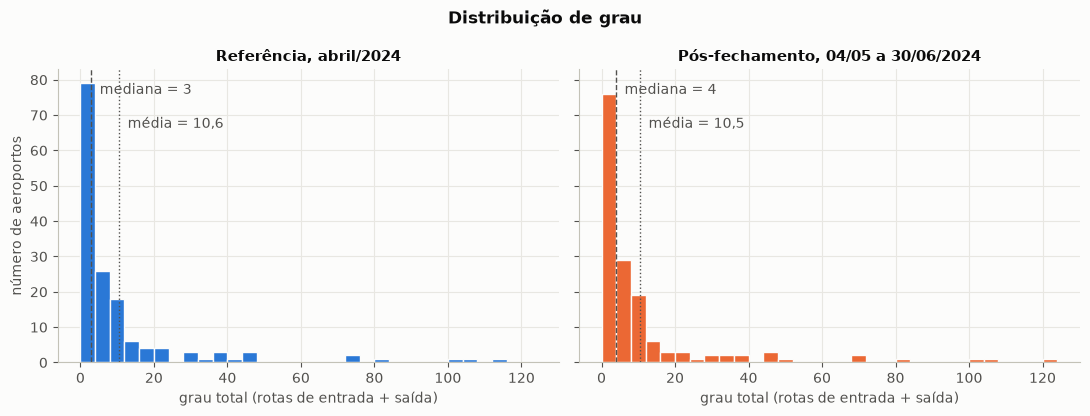

In [5]:
g_ref = np.array([g for _, g in G_ref.degree()])
g_pos = np.array([g for _, g in G_pos.degree()])

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
bins = np.arange(0, max(g_ref.max(), g_pos.max()) + 5, 4)

for ax, g, cor, titulo in [(eixos[0], g_ref, COR_REF, "Referência, abril/2024"),
                           (eixos[1], g_pos, COR_POS, "Pós-fechamento, 04/05 a 30/06/2024")]:
    ax.hist(g, bins=bins, color=cor, edgecolor="#fcfcfb", linewidth=1)
    topo = 80
    ax.axvline(np.median(g), color="#52514e", linestyle="--", linewidth=1)
    ax.axvline(g.mean(), color="#52514e", linestyle=":", linewidth=1)
    ax.annotate(f"mediana = {np.median(g):.0f}", (np.median(g), topo * 0.95),
                xytext=(6, 0), textcoords="offset points", color="#52514e")
    ax.annotate(f"média = {g.mean():.1f}".replace(".", ","), (g.mean(), topo * 0.83),
                xytext=(6, 0), textcoords="offset points", color="#52514e")
    ax.set(title=titulo, xlabel="grau total (rotas de entrada + saída)")
eixos[0].set_ylabel("número de aeroportos")
fig.suptitle("Distribuição de grau", fontweight="bold")

fig.tight_layout()
fig.savefig(PASTA_FIG / "01_distribuicao_grau.png", dpi=150)
plt.show()

In [6]:
folhas = [n for n in G_ref if G_ref.degree(n) == 2]
um_vizinho = [n for n in folhas if len(set(G_ref.predecessors(n)) | set(G_ref.successors(n))) == 1]
hubs = [n for n in G_ref if G_ref.degree(n) >= 70]
print(f"aeroportos com grau total 2: {len(folhas)} ({len(folhas) / len(G_ref):.0%})")
print(f"  destes, ligados a um único aeroporto (ida e volta): {len(um_vizinho)}")
print(f"aeroportos com grau total >= 70: {len(hubs)} -> {[nome_curto(G_ref, n) for n in hubs]}")
top10 = graus_ref.head(10)["grau total"].sum()
print(f"os 10 maiores concentram {top10 / (2 * G_ref.number_of_edges()):.0%} das pontas de rota")

aeroportos com grau total 2: 70 (45%)
  destes, ligados a um único aeroporto (ida e volta): 58
aeroportos com grau total >= 70: 6 -> ['Viracopos (SP)', 'Brasília (DF)', 'Tancredo Neves (MG)', 'Guarulhos (SP)', 'Guararapes (PE)', 'Congonhas (SP)']
os 10 maiores concentram 44% das pontas de rota


- A distribuição é muito assimétrica. **70 aeroportos (45%) têm grau total 2**: uma rota de chegada e uma de saída. Em **58 deles as duas rotas são com o mesmo aeroporto**: são pontas de linha que dependem de um único vizinho. Se esse vizinho fecha, o aeroporto fica isolado.
- No outro extremo, **6 aeroportos têm grau 70 ou mais**: Viracopos, Guarulhos, Confins (Tancredo Neves), Congonhas, Recife (Guararapes) e Brasília. Os 10 maiores concentram **44% das pontas de rota**.
- A média (10,6) é mais de três vezes a mediana (3): o histograma tem uma barra alta à esquerda e uma cauda longa à direita, formada por poucos hubs.
- Os dois histogramas são praticamente iguais. A forma da distribuição não mudou com o fechamento de POA.
- **Relação com H1:** numa rede concentrada em poucos hubs, um aeroporto sorteado ao acaso quase sempre é periférico. Por isso se espera robustez a falhas aleatórias e fragilidade a fechamentos direcionados aos hubs.

Figura salva em `figures/01_distribuicao_grau.png`.

## 4. Aeroportos mais conectados, antes e depois do fechamento de POA (Sem. 2)

In [7]:
graus_pos = tabela_graus(G_pos)
top = pd.DataFrame({
    "abril": [f"{nome_curto(G_ref, n)}: {g}" for n, g in graus_ref["grau total"].head(12).items()],
    "mai-jun": [f"{nome_curto(G_pos, n)}: {g}" for n, g in graus_pos["grau total"].head(12).items()],
}, index=range(1, 13))
top

,abril,mai-jun
1,Viracopos (SP): 112,Viracopos (SP): 120
2,Guarulhos (SP): 104,Guarulhos (SP): 104
3,Tancredo Neves (MG): 102,Tancredo Neves (MG): 102
4,Congonhas (SP): 80,Congonhas (SP): 82
5,Guararapes (PE): 72,Guararapes (PE): 69
6,Brasília (DF): 72,Brasília (DF): 68
7,Galeão (RJ): 46,Galeão (RJ): 48
8,Val de Cans (PA): 45,Val de Cans (PA): 44
9,Eduardo Gomes (AM): 45,Pinto Martins (CE): 44
10,Salgado Filho (RS): 40,Eduardo Gomes (AM): 44


In [8]:
for icao in ["SBPA", "SBCO"]:
    for nome, G in [("abril", G_ref), ("mai-jun", G_pos)]:
        if icao in G:
            vizinhos = sorted(set(G.predecessors(icao)) | set(G.successors(icao)))
            print(f"{nome_curto(G, icao)} em {nome}: grau {G.degree(icao)}, ligado a {len(vizinhos)} aeroportos")
        else:
            print(f"{icao} em {nome}: fora da rede")
vizinhos_co = sorted(set(G_pos.predecessors("SBCO")) | set(G_pos.successors("SBCO")))
print("vizinhos de Canoas:", [nome_curto(G_pos, n) for n in vizinhos_co])

Salgado Filho (RS) em abril: grau 40, ligado a 20 aeroportos
SBPA em mai-jun: fora da rede
SBCO em abril: fora da rede
Canoas (RS) em mai-jun: grau 6, ligado a 3 aeroportos
vizinhos de Canoas: ['Guarulhos (SP)', 'Viracopos (SP)', 'Congonhas (SP)']


- O **Salgado Filho era o 10º aeroporto em grau** em abril (grau 40, ligado a 20 aeroportos) e sai da rede.
- **Canoas (SBCO)** entra com grau 6, ligada **só a Guarulhos, Viracopos e Congonhas**. Ela absorveu as ligações com São Paulo, mas não as rotas regionais e para as outras capitais que o Salgado Filho tinha (3 vizinhos contra 20).
- Os seis primeiros do ranking são os mesmos nos dois períodos. Viracopos ganha 8 rotas (de 112 para 120); se isso tem relação com POA, a comparação entre a simulação e a malha real vai mostrar.

## 5. Componentes, caminhos e diâmetro (Sem. 4)

In [9]:
for nome, G in [("abril", G_ref), ("mai-jun", G_pos)]:
    sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
    fora = [n for c in sccs[1:] for n in c]
    print(f"{nome}: {nx.number_weakly_connected_components(G)} WCC, {len(sccs)} SCC, "
          f"maior SCC com {len(sccs[0])} de {len(G)}; fora: {[nome_curto(G, n) for n in fora]}")
    for n in fora:
        print(f"   {nome_curto(G, n)}: chega de {[nome_curto(G, p) for p in G.predecessors(n)]}, "
              f"sai para {[nome_curto(G, s) for s in G.successors(n)]}")

abril: 1 WCC, 2 SCC, maior SCC com 153 de 154; fora: ['Iguatu (CE)']
   Iguatu (CE): chega de ['Pinto Martins (CE)'], sai para []
mai-jun: 1 WCC, 1 SCC, maior SCC com 153 de 153; fora: []


In [10]:
S = G_ref.subgraph(max(nx.strongly_connected_components(G_ref), key=len))
dist = dict(nx.all_pairs_shortest_path_length(S))
diam = max(max(d.values()) for d in dist.values())
pares = [(u, v) for u in dist for v, d in dist[u].items() if d == diam]
print(f"diâmetro da maior SCC em abril: {diam} voos ({diam - 1} escalas); pares: {len(pares)}")
u, v = pares[0]
print(" -> ".join(nome_curto(G_ref, n) for n in nx.shortest_path(S, u, v)))

hist = pd.Series([d for u in dist for v, d in dist[u].items() if u != v]).value_counts(normalize=True).sort_index()
print("\nfração dos pares por número de voos no menor caminho:")
print(pd.DataFrame({"voos": hist.index, "pares (%)": (100 * hist.values).round(1)}).to_string(index=False))

diâmetro da maior SCC em abril: 7 voos (6 escalas); pares: 2
Aripuanã (MT) -> Juína (MT) -> Marechal Rondon (MT) -> Viracopos (SP) -> Eduardo Gomes (AM) -> Trombetas (PA) -> Oriximiná (PA) -> Monte Alegre (PA)

fração dos pares por número de voos no menor caminho:
 voos  pares (%)
    1        3.5
    2       32.3
    3       46.1
    4       14.9
    5        2.9
    6        0.2
    7        0.0


- A rede tem **uma única componente fracamente conexa** nos dois períodos: não há aeroporto totalmente isolado.
- Em abril há **duas componentes fortemente conexas**. Iguatu (CE) recebe voo de Fortaleza, mas não tem voo de saída acima do limiar: dá para chegar, mas não para sair. É um exemplo de por que a direção importa. Em maio e junho, todos os aeroportos estão numa única SCC.
- O **diâmetro é de 7 voos (6 escalas)**. Só dois pares estão a essa distância; o caminho mostrado acima vai de Aripuanã (MT) a Monte Alegre (PA), passando por Cuiabá, Viracopos e Manaus.
- **82% dos pares se ligam com até 3 voos** (no máximo 2 escalas), e só 3,5% têm voo direto. Essa é a linha de base de escalas que os fechamentos vão alterar.

## 6. Matriz de adjacência (Sem. 2)

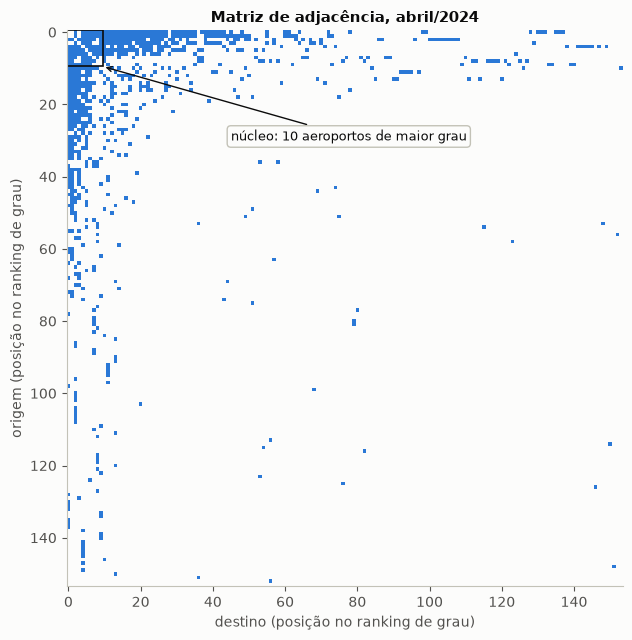

In [11]:
ordem = list(graus_ref.index)
A = nx.to_numpy_array(G_ref, nodelist=ordem, weight=None)

from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
k = 10
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(A, cmap=ListedColormap(["#fcfcfb", COR_REF]), interpolation="nearest")
ax.grid(False)
ax.add_patch(Rectangle((-0.5, -0.5), k, k, fill=False, edgecolor="#0b0b0b", linewidth=1.2))
ax.annotate(f"núcleo: {k} aeroportos de maior grau", xy=(k - 0.5, k - 0.5), xytext=(45, 30),
            color="#0b0b0b", fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="#fcfcfb", ec="#c3c2b7"),
            arrowprops=dict(arrowstyle="->", color="#0b0b0b", linewidth=1))
ax.set_title("Matriz de adjacência, abril/2024")
ax.set_xlabel("destino (posição no ranking de grau)")
ax.set_ylabel("origem (posição no ranking de grau)")
fig.tight_layout()
fig.savefig(PASTA_FIG / "01_matriz_adjacencia.png", dpi=150)
plt.show()

In [12]:
bloco_nucleo = A[:k, :k].sum() / (k * (k - 1))
resto = A[k:, k:].sum() / ((len(A) - k) * (len(A) - k - 1))
print(f"densidade entre os {k} maiores: {bloco_nucleo:.0%}")
print(f"densidade entre os outros {len(A) - k}: {resto:.1%}")
liga_top = sum(1 for n in ordem[k:] if set(G_ref.successors(n)) & set(ordem[:k]))
print(f"aeroportos fora do top {k} com rota para algum do top {k}: {liga_top} de {len(A) - k}")

densidade entre os 10 maiores: 82%
densidade entre os outros 144: 0.8%
aeroportos fora do top 10 com rota para algum do top 10: 116 de 144


- Com os aeroportos ordenados por grau, a matriz mostra um **bloco denso no canto superior esquerdo**: a densidade entre os 10 maiores é de **82%**, contra **0,8%** entre os outros 144.
- A **faixa vertical à esquerda** mostra que **116 dos 144 aeroportos** fora do top 10 têm rota para pelo menos um dos 10 maiores. A periferia quase não se liga entre si: ela se liga ao núcleo.
- Esse é o desenho de uma estrutura **núcleo-periferia** (subpergunta 1), que será medida com k-core (Sem. 5) no próximo notebook.

Figura salva em `figures/01_matriz_adjacencia.png`.

## 7. Triângulos e clustering (Sem. 4)

In [13]:
U = G_ref.to_undirected()
print(f"clustering médio da malha: {nx.average_clustering(U):.3f}")
print(f"triângulos na malha: {sum(nx.triangles(U).values()) // 3}")

clust = pd.Series(nx.clustering(U))
grupos = pd.cut(pd.Series(dict(U.degree())), bins=[0, 2, 10, 30, 200], labels=["1 a 2", "3 a 10", "11 a 30", "mais de 30"])
clust.groupby(grupos, observed=True).agg(["count", "mean"]).rename(columns={"count": "aeroportos", "mean": "clustering médio"}).rename_axis("vizinhos")

clustering médio da malha: 0.384
triângulos na malha: 700


,aeroportos,clustering médio
vizinhos,,
1 a 2,91,0.264
3 a 10,43,0.657
11 a 30,14,0.427
mais de 30,6,0.163


- O clustering médio da malha é **0,38**, com **700 triângulos**.
- O clustering varia muito com o número de vizinhos. É **mais alto nos aeroportos médios** (3 a 10 vizinhos, 0,66): seus vizinhos costumam ter rota entre si, o que cria **caminhos alternativos** quando um deles fecha.
- É **baixo nos hubs** (mais de 30 vizinhos, 0,16): eles ligam muitos aeroportos periféricos que não têm rota entre si. Esses caminhos dependem do hub, o que antecipa por que fechar um hub deve doer.
- Os aeroportos com 1 ou 2 vizinhos têm o menor potencial de alternativa: os 58 que dependem de um único vizinho (seção 3) têm clustering zero por definição.

## Resumo

- A malha é **esparsa** (3,5% dos pares com voo direto) e **concentrada**: mediana de grau 3, enquanto 6 aeroportos têm grau 70 ou mais.
- É **quase simétrica** (95% das rotas com volta), tem uma única componente fraca e praticamente uma única SCC.
- Tem um **núcleo denso e uma periferia dependente**: 58 aeroportos se ligam a um único vizinho, e os hubs têm clustering baixo.
- A malha pós-fechamento é quase igual nos números globais. Canoas substitui o Salgado Filho só nas ligações com São Paulo.

**Próximos passos:** centralidades e comparação entre hubs e pontes (H2), k-core e núcleo-periferia (subpergunta 1), e simulação de fechamentos (H1 e H3).

## Lembrete: ferramentas complementares a avaliar

Verificar se vale incluir alguma ferramenta de fora do curso como complemento. Se entrar, lembrar de citar em "Referências" no README.

Candidatas já identificadas para este notebook:

- [ ] **CCDF em escala log-log** da distribuição de grau: mostra melhor a cauda dos hubs que o histograma.
- [ ] **Comparação com grafo aleatório** de mesmo tamanho (`nx.gnm_random_graph`): dá uma referência para dizer se o clustering é alto ou baixo.